In [ ]:
!git clone https://github.com/RuslanGreenhead/zeroth_order_resnet.git -q
!pip install -r zeroth_order_resnet/requirements.txt -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 3.8 MB/s eta 0:00:00


In [ ]:
import sys
sys.path.insert(0, "/content/zeroth_order_resnet")

In [ ]:
from __future__ import annotations

import os, random
import numpy as np
import matplotlib.pyplot as plt
import argparse
import json
import sys

import torch
from torch import optim, nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import torchvision.datasets as datasets
from typing import Union, Callable, List, Dict, Any

from augmentation import get_transforms
from model import get_model, get_model_imagenet_head
# from zo_optimizer import ZeroOrderOptimizer
from train_data import get_train_dataset_loader

#### 1.1) DeepZero optimizer implementation

In [ ]:
from dataclasses import dataclass


@dataclass
class ZOConfig:
    a: float = 1e-2
    mu: float = 1e-3
    n_coords: int = 1024
    clip_value: float = 1.0
    momentum: float = 0.9
    eps: float = 1e-8
    use_symmetric: bool = True
    layer_sampling: bool = True
    max_per_layer: int = 256


class DeepZeroOptimizer:
    def __init__(self, model: nn.Module, layer_names: List[str], config: ZOConfig):
        self.model = model
        self.layer_names = layer_names
        self.cfg = config
        self.sum_squared_grads = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
        self.velocity = {n: torch.zeros_like(p) for n, p in model.named_parameters()}

    def _named_params(self) -> Dict[str, nn.Parameter]:
        named = dict(self.model.named_parameters())
        missing = [n for n in self.layer_names if n not in named]
        if missing:
            raise KeyError(f"Missed params: {missing}")
        return {n: named[n] for n in self.layer_names}

    def _eval_loss(self, loss_fn: Callable[[], torch.Tensor | float]) -> float:
        out = loss_fn()
        if isinstance(out, torch.Tensor):
            return float(out.detach().item())
        return float(out)

    @torch.no_grad()
    def _estimate_grad(self, loss_fn: Callable[[], torch.Tensor | float]) -> Dict[str, torch.Tensor]:
        params = self._named_params()
        backup = {n: p.detach().clone() for n, p in params.items()}
        grads = {n: torch.zeros_like(p) for n, p in params.items()}

        base_loss = self._eval_loss(loss_fn)
        layer_items = list(params.items())

        if self.cfg.layer_sampling:
            layer_probs = torch.tensor([p.numel() for _, p in layer_items], device=next(iter(params.values())).device, dtype=torch.float32)
            layer_probs = layer_probs / layer_probs.sum()
            n_layers = min(len(layer_items), max(1, self.cfg.n_coords // max(1, self.cfg.max_per_layer)))
            chosen_layers = torch.multinomial(layer_probs, n_layers, replacement=True).tolist()
        else:
            chosen_layers = list(range(len(layer_items)))

        total_budget = self.cfg.n_coords

        for li in chosen_layers:
            name, param = layer_items[li]
            flat = param.view(-1)
            gflat = grads[name].view(-1)
            budget = min(self.cfg.max_per_layer, total_budget, flat.numel())
            if budget <= 0:
                continue

            idx = torch.randperm(flat.numel(), device=flat.device)[:budget]

            for i in idx:
                orig = flat[i].item()

                if self.cfg.use_symmetric:
                    flat[i] = orig + self.cfg.mu
                    f_plus = self._eval_loss(loss_fn)
                    flat[i] = orig - self.cfg.mu
                    f_minus = self._eval_loss(loss_fn)
                    flat[i] = orig
                    gflat[i] = (f_plus - f_minus) / (2.0 * self.cfg.mu)
                else:
                    flat[i] = orig + self.cfg.mu
                    f_plus = self._eval_loss(loss_fn)
                    flat[i] = orig
                    gflat[i] = (f_plus - base_loss) / self.cfg.mu

            total_budget -= budget
            if total_budget <= 0:
                break

        for n, p in params.items():
            p.copy_(backup[n])

        return grads

    @torch.no_grad()
    def step(self, loss_fn: Callable[[], torch.Tensor | float]) -> float:
        loss_before = self._eval_loss(loss_fn)
        grads = self._estimate_grad(loss_fn)

        for n in grads:
            grads[n].clamp_(-self.cfg.clip_value, self.cfg.clip_value)

        for name, param in self.model.named_parameters():
            if name not in grads:
                continue
            g = grads[name]

            self.sum_squared_grads[name].add_(g * g)
            lr = self.cfg.a / (self.sum_squared_grads[name].sqrt() + self.cfg.eps)

            if self.cfg.momentum > 0:
                self.velocity[name].mul_(self.cfg.momentum).add_(lr * g)
                param.add_(-self.velocity[name])
            else:
                param.add_(-lr * g)

        return loss_before

#### 1.2) SPSA optimizer implementation

In [ ]:
@dataclass
class SPSAConfig:
    a: float = 1e-2
    c: float = 1e-3
    alpha: float = 0.602
    gamma: float = 0.101
    A: float = 10.0
    clip_value: float = 1.0
    momentum: float = 0.0
    eps: float = 1e-8
    n_avg: int = 1


class SPSAOptimizer:
    def __init__(
        self,
        model: nn.Module,
        layer_names: List[str],
        cfg: SPSAConfig,
    ):
        self.model = model
        self.layer_names = layer_names
        self.cfg = cfg

        self.sum_squared_grads = {
            n: torch.zeros_like(p) for n, p in model.named_parameters()
        }
        self.velocity = {
            n: torch.zeros_like(p) for n, p in model.named_parameters()
        }

    def _active_params(self) -> Dict[str, nn.Parameter]:
        named = dict(self.model.named_parameters())
        missing = [n for n in self.layer_names if n not in named]
        if missing:
            raise KeyError(
                f"Missed params: {missing}."
            )
        return {n: named[n] for n in self.layer_names}

    def _eval_loss(self, loss_fn: Callable[[], torch.Tensor | float]) -> float:
        out = loss_fn()
        return float(out.detach().item()) if isinstance(out, torch.Tensor) else float(out)

    @torch.no_grad()
    def _estimate_grad(self, loss_fn: Callable[[], torch.Tensor | float]) -> Dict[str, torch.Tensor]:
        params = self._active_params()
        backup = {name: p.detach().clone() for name, p in params.items()}
        grads = {name: torch.zeros_like(p) for name, p in params.items()}

        n_avg = max(1, self.cfg.n_avg)
        for _ in range(n_avg):
            delta = {}
            for name, p in params.items():
                sign = torch.randint(0, 2, p.shape, device=p.device)
                d = torch.where(sign == 0, -torch.ones_like(p), torch.ones_like(p))
                delta[name] = d

            for name, p in params.items():
                p.add_(self.cfg.c * delta[name])
            f_plus = self._eval_loss(loss_fn)

            for name, p in params.items():
                p.add_(-2.0 * self.cfg.c * delta[name])
            f_minus = self._eval_loss(loss_fn)

            for name, p in params.items():
                p.add_(self.cfg.c * delta[name])

            for name in params:
                grads[name].add_((f_plus - f_minus) / (2.0 * self.cfg.c) * delta[name])

        for name in grads:
            grads[name].div_(float(n_avg))

        for name, p in params.items():
            p.copy_(backup[name])

        return grads

    @torch.no_grad()
    def step(self, loss_fn: Callable[[], torch.Tensor | float]) -> float:
        loss_before = self._eval_loss(loss_fn)
        grads = self._estimate_grad(loss_fn)

        for name in grads:
            grads[name].clamp_(-self.cfg.clip_value, self.cfg.clip_value)

        lr = self.cfg.a / ((1.0 + self.cfg.A) ** self.cfg.alpha)

        for name, param in self.model.named_parameters():
            if name not in grads:
                continue

            g = grads[name]
            self.sum_squared_grads[name].add_(g.pow(2))
            adaptive = lr / (self.sum_squared_grads[name].sqrt() + self.cfg.eps)

            if self.cfg.momentum > 0:
                self.velocity[name].mul_(self.cfg.momentum).add_(adaptive * g)
                param.add_(-self.velocity[name])
            else:
                param.add_(-adaptive * g)

        return loss_before

In [ ]:
class MetaOptimizer:
    def __init__(self, model, layer_names, dz_cfg, spsa_cfg, n_spsa_steps=1, n_dz_steps=5):
        self.spsa_opt = SPSAOptimizer(model, layer_names, spsa_cfg)
        self.deepzero_opt = DZ2Optimizer(model, layer_names, dz_cfg)
        self.n_spsa_steps = n_spsa_steps
        self.n_dz_steps = n_dz_steps
        self.step_cnt = 0

    def _schedule_opt(self):
        step_within_cycle = self.step_cnt % (self.n_dz_steps + self.n_spsa_steps)
        if step_within_cycle <= self.n_spsa_steps:
            return self.spsa_opt
        else:
            return self.deepzero_opt

    def step(self, *args, **kwargs):
        opt_output = self._schedule_opt().step(*args, **kwargs)
        self.step_cnt += 1

        return opt_output


#### 2) Experiments functions

In [ ]:
_MAX_BUDGET = 8192  # Maximum allowed total samples (n_batches × batch_size)


def seed_everything(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # For reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # PyTorch deterministic algorithms
    torch.use_deterministic_algorithms(True, warn_only=True)

In [ ]:
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    desc: str = "Evaluating",
) -> float:
    """Compute top-1 accuracy of ``model`` on the given data loader.

    Args:
        model:  The model to evaluate. Called in eval mode with no_grad.
        loader: DataLoader yielding (images, labels) batches.
        device: Device on which to run inference.
        desc:   Label shown in the progress bar.

    Returns:
        Top-1 accuracy as a float in [0, 1].
    """
    model.eval()
    model.to(device)

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"  {desc}", leave=False, unit="batch"):
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            total += labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()

    return correct / total

In [ ]:
def run_finetuning(
    model: nn.Module,
    train_loader: DataLoader,
    optimizer: Union[SPSAOptimizer, DeepZeroOptimizer],
    n_batches: int,
    device: torch.device,
    criterion: nn.Module,
) -> None:
    """Run zero-order fine-tuning for exactly ``n_batches`` steps.

    On each step a fresh batch is drawn from ``train_loader`` and a closure
    ``loss_fn`` is constructed that evaluates the model on that fixed batch.
    The closure is passed to ``optimizer.step()``.

    The compute budget is enforced strictly — ``.step()`` is called exactly
    ``n_batches`` times regardless of the number of loss evaluations performed
    inside each step.

    Args:
        model:        The model being fine-tuned (modified in-place).
        train_loader: DataLoader for the CIFAR100 training split (cycling).
        optimizer:    Instantiated ``ZeroOrderOptimizer``.
        n_batches:    Total number of optimiser steps to perform.
        device:       Device on which to run inference.
        criterion:    Loss function (e.g. ``nn.CrossEntropyLoss()``).
    """
    model.to(device)


    def _infinite(loader: DataLoader):
        while True:
            yield from loader

    data_iter = _infinite(train_loader)
    output = {k: np.empty(n_batches) for k in ["train_losses", "grad_norms"]}

    pbar = tqdm(range(n_batches), desc="  Fine-tuning", unit="step")
    for step_idx in pbar:
        images, labels = next(data_iter)
        images = images.to(device)
        labels = labels.to(device)

        # closure for first order tuning (for the sake of comparison)
        def loss_fn() -> torch.Tensor:
            model.train()  # to implement basic SGD training
            logits = model(images)
            return criterion(logits, labels)


        # ZO branch
        if isinstance(optimizer, (SPSAOptimizer, DeepZeroOptimizer, DZ2Optimizer)):

            # closure for ZO
            def closure_float(_images=images, _labels=labels) -> float:
                model.eval()
                with torch.no_grad():
                    logits = model(_images)
                    loss = criterion(logits, _labels)
                return float(loss.item())

            loss = optimizer.step(closure_float)
            grad_norm = torch.norm(next(iter(optimizer._estimate_grad(closure_float).values())))
            print(f"Grad norm: {grad_norm:.4f}")  # aim at -> 0.01-0.1
            pbar.set_postfix(loss=f"{loss:.4f}")

            # save history
            output["train_losses"][step_idx] = loss
            output["grad_norms"][step_idx] = grad_norm

        # SGD branch
        else:
            optimizer.zero_grad()
            loss = loss_fn()
            loss.backward()
            optimizer.step()

            pbar.set_postfix(loss=f"{loss.item():.4f}")

    pbar.close()

    return output

In [ ]:
def _fmt(value: float, full=False) -> str:
    return value if full else f"{value * 100:.2f}%"


def print_summary(results: dict) -> None:
    """Print a formatted summary table of the three evaluation checkpoints.

    Args:
        results: Dict containing accuracy values and run configuration.
    """
    print("\n" + "=" * 60)
    print(" Evaluation Summary")
    print("=" * 60)
    print(f"  {'Checkpoint':<30} {'Top-1':>8}")
    print("-" * 60)

    rows = [
        ("1. Baseline (ImageNet head)", results["val_accuracy_top1_imagenet_head"]),
        ("2. Initialized head (no FT)", results["val_accuracy_top1_init_head"]),
        ("3. Fine-tuned (ZO)",          results["val_accuracy_top1_finetuned"]),
    ]
    for label, top1 in rows:
        print(f"  {label:<30} {_fmt(top1):>8}")

    print("-" * 60)
    print(
        f"  Budget: {results['n_batches']} steps × batch {results['batch_size']} "
        f"= {results['n_batches'] * results['batch_size']:,} / {_MAX_BUDGET} samples"
    )
    layers = results.get("layers_tuned") or ["(none)"]
    print(f"  Layers tuned: {', '.join(layers)}")
    print(f"  Val samples:  {results['total_samples']:,}")
    print("=" * 60 + "\n")

#### 2) Running Experiments in notebook

In [ ]:
DATA_DIR = "./data"
BATCH_SIZE = 128
N_BATCHES = 32
SEED = 42
OUTPUT = "results.json"

In [ ]:
seed_everything(SEED)
generator_train = torch.Generator()
generator_train.manual_seed(SEED)

# ------------------------------------------------------------------
# Budget enforcement
# ------------------------------------------------------------------
# total_budget = N_BATCHES * BATCH_SIZE
# if total_budget > _MAX_BUDGET:
#     print(
#         f"[Error] Total compute budget (n_batches × batch_size = "
#         f"{N_BATCHES} × {BATCH_SIZE} = {total_budget:,}) "
#         f"exceeds the maximum allowed budget of {_MAX_BUDGET:,}.\n"
#         f"        Reduce --n_batches or --batch_size so that their "
#         f"product is ≤ {_MAX_BUDGET}.",
#         file=sys.stderr,
#     )
#     sys.exit(1)

device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print(f"[Device] Using: {device}")

[Device] Using: cuda


In [ ]:
# ------------------------------------------------------------------
# Data loaders
# ------------------------------------------------------------------
print(f"[Data] Loading CIFAR100 from '{DATA_DIR}' ...")

train_dataset, train_loader = get_train_dataset_loader(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    generator_train=generator_train,
    augment_mode=1
)
val_dataset = datasets.CIFAR100(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=get_transforms(train=False),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print(
    f"[Data] Train: {len(train_dataset):,} samples | "
    f"Val: {len(val_dataset):,} samples"
)

criterion = nn.CrossEntropyLoss()

[Data] Loading CIFAR100 from './data' ...
[Data] Train: 50,000 samples | Val: 10,000 samples


In [ ]:
# ------------------------------------------------------------------
# Checkpoint 1: Baseline — ImageNet head
# ------------------------------------------------------------------
# print("\n[Checkpoint 1/3] Baseline (ImageNet head)")
model_imagenet = get_model_imagenet_head()
top1_imagenet = evaluate(model_imagenet, val_loader, device, desc="Baseline eval")
print(f"  Top-1: {_fmt(top1_imagenet)}")
del model_imagenet

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]
                                                                     

  Top-1: 0.37%


In [ ]:
# ------------------------------------------------------------------
# Checkpoint 2: Initialized head — no fine-tuning
# ------------------------------------------------------------------
# print("\n[Checkpoint 2/3] Initialized head (no fine-tuning)")
model = get_model()
top1_init = evaluate(model, val_loader, device, desc="Init-head eval")
w_init = model.fc.weight.detach().cpu().clone()
print(f"Top-1: {_fmt(top1_init, full=True)}")

Top-1: 0.0044


In [ ]:
[n for n, _ in model.named_parameters()]

['conv1.weight',
 'bn1.weight',
 'bn1.bias',
 'layer1.0.conv1.weight',
 'layer1.0.bn1.weight',
 'layer1.0.bn1.bias',
 'layer1.0.conv2.weight',
 'layer1.0.bn2.weight',
 'layer1.0.bn2.bias',
 'layer1.1.conv1.weight',
 'layer1.1.bn1.weight',
 'layer1.1.bn1.bias',
 'layer1.1.conv2.weight',
 'layer1.1.bn2.weight',
 'layer1.1.bn2.bias',
 'layer2.0.conv1.weight',
 'layer2.0.bn1.weight',
 'layer2.0.bn1.bias',
 'layer2.0.conv2.weight',
 'layer2.0.bn2.weight',
 'layer2.0.bn2.bias',
 'layer2.0.downsample.0.weight',
 'layer2.0.downsample.1.weight',
 'layer2.0.downsample.1.bias',
 'layer2.1.conv1.weight',
 'layer2.1.bn1.weight',
 'layer2.1.bn1.bias',
 'layer2.1.conv2.weight',
 'layer2.1.bn2.weight',
 'layer2.1.bn2.bias',
 'layer3.0.conv1.weight',
 'layer3.0.bn1.weight',
 'layer3.0.bn1.bias',
 'layer3.0.conv2.weight',
 'layer3.0.bn2.weight',
 'layer3.0.bn2.bias',
 'layer3.0.downsample.0.weight',
 'layer3.0.downsample.1.weight',
 'layer3.0.downsample.1.bias',
 'layer3.1.conv1.weight',
 'layer3.1.bn1.

In [ ]:
# Calibration of (a) and (c) parameters for SPSA
from head_init import init_last_layer

model = get_model()
model.to(device)
init_last_layer(model.fc, mode='kaiming')

layer_names = ["fc.weight", "fc.bias"]


cfg = ZOConfig()
optimizer = DeepZeroOptimizer(
    model,
    layer_names,
    cfg
)

# calib_iter = iter(train_loader)

# def calibration_loss_fn() -> float:
#     model.eval()
#     with torch.no_grad():
#         # load a small batch or reuse a loader
#         images, labels = next(iter(train_loader))     # or separate calib_loader here
#         images = images.to(device)
#         labels = labels.to(device)
#         logits = model(images)
#         loss = criterion(logits, labels)
#     return float(loss.item())

# calib = optimizer.calibrate(
#     loss_fn=calibration_loss_fn
# )

# print(f"Calibrated: mu={optimizer.mu:.2e}")

In [ ]:
model.fc.bias.numel() + model.fc.weight.numel()

51300

In [ ]:
# ------------------------------------------------------------------
# Checkpoint 3: Fine-tuned
# ------------------------------------------------------------------
from head_init import init_last_layer


# Try SGD
# - - - - - - - - - - - - - - - - - - - - - - - - -
# model = get_model()
# model.to(device)
# init_last_layer(model.fc, mode='xavier')

# layer_names = ["fc.weight", "fc.bias"]
# selected_params = []
# for name, param in model.named_parameters():
#     if name in layer_names:
#         selected_params.append(param)

# # optimizer = optim.SGD(
# #     params=model.parameters(),
# #     lr=0.01,                 # typical for head‑only fine‑tuning
# #     momentum=0.9,
# #     weight_decay=1e-4,
# # )
# optimizer = optim.AdamW(
#     params=selected_params,
#     lr=1e-2,
#     weight_decay=1e-4,
# )

# print(f"  Active layers: {optimizer.layer_names}")

output = run_finetuning(
    model=model,
    train_loader=train_loader,
    optimizer=optimizer,
    n_batches=N_BATCHES,
    device=device,
    criterion=criterion
)

print("  Evaluating fine-tuned model ...")
top1_ft = evaluate(model, val_loader, device, desc="Fine-tuned eval")
w_ft = model.fc.weight.detach().cpu().clone()
print(f"Top-1: {_fmt(top1_ft, full=True)}")

  Fine-tuning:   0%|          | 0/32 [00:00<?, ?step/s]

333


  Fine-tuning:   3%|▎         | 1/32 [03:47<1:57:29, 227.40s/step, loss=5.7909]

Grad norm: 0.3454
333


  Fine-tuning:   6%|▋         | 2/32 [07:38<1:54:47, 229.58s/step, loss=5.7336]

...

  Fine-tuning:  97%|█████████▋| 31/32 [1:59:18<03:51, 231.92s/step, loss=4.9212]

Grad norm: 0.3008
333


  Fine-tuning: 100%|██████████| 32/32 [2:03:09<00:00, 230.94s/step, loss=4.8218]


Grad norm: 0.2299
  Evaluating fine-tuned model ...


Top-1: 0.0381


In [ ]:
def plot_train_dynamics(output):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    ax1.plot(output['train_losses'], color="tab:blue")
    ax1.set_title("Train loss")
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Loss")

    ax2.plot(output['grad_norms'], color="tab:orange")
    ax2.set_title("Grad norms")
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Norm")

    return fig, (ax1, ax2)

In [ ]:
type(output)

dict

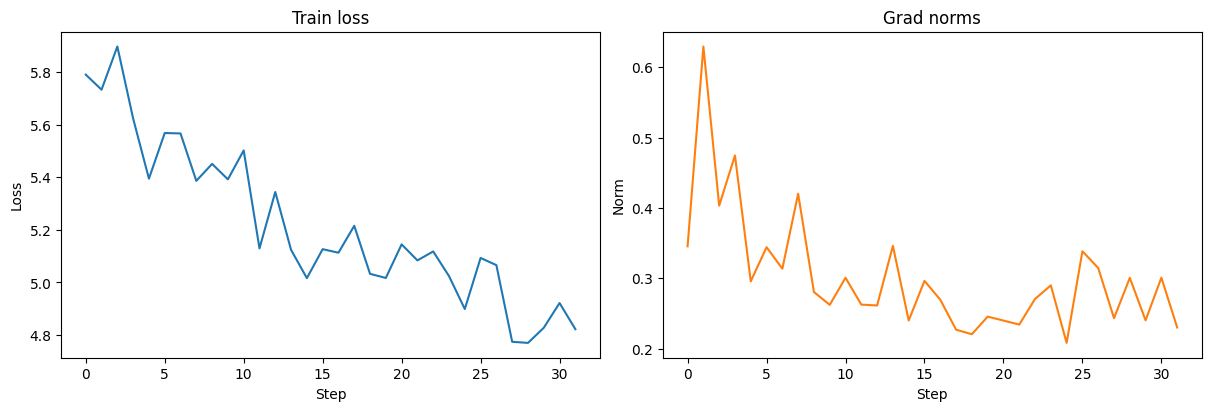

In [ ]:
fig, axes = plot_train_dynamics(output)
plt.show()

In [ ]:
import pickle
from google.colab import drive

drive.mount('/content/drive')

with open("", "wb") as f:
    pickle.dump(output, f)

#### 2) Fixing issues

In [ ]:
with torch.no_grad():
    for images, labels in tqdm(train_loader, leave=False, unit="batch"):
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        print(logits.argmax(dim=1))
        print(labels)
        print((logits.argmax(dim=1) == labels).sum())
        break
        # total += labels.size(0)
        # correct += (logits.argmax(dim=1) == labels).sum().item()

tensor([48, 26, 46, 84, 24, 26,  4,  5, 46, 26, 93,  5, 46, 48, 48, 84, 26, 84,
        26, 26, 26, 41, 93, 92, 41, 91, 92, 92, 41, 93, 48, 24, 41, 58, 91, 48,
         5, 29, 46, 90, 26, 92, 60, 46, 46,  5, 92, 51, 51, 41,  3, 85, 22, 26,
        93, 93, 67, 84,  5,  5, 69, 41, 91, 41], device='cuda:0')
tensor([63, 82, 76, 26, 34,  1, 11,  2, 69, 66, 57, 69, 71, 48,  6, 32, 84, 28,
         6, 35, 63, 87, 51, 20, 75, 52,  3, 98, 89, 97, 56, 83,  8, 37, 55, 66,
        30, 79, 60, 36, 77,  3, 86, 64, 52, 31, 42, 97, 54,  0, 22, 37, 10, 56,
        42, 91, 86, 69, 75, 47, 11, 39, 68, 13], device='cuda:0')
tensor(1, device='cuda:0')


In [ ]:
torch.norm(w_init - w_ft, p=2)

tensor(11.7431)

In [ ]:
print([f"{val:.10f}" for val in (top1_ft, top1_init)])

['0.0133000000', '0.0095000000']


In [ ]:
# ------------------------------------------------------------------
# Save results
# ------------------------------------------------------------------
results = {
    "val_accuracy_top1_imagenet_head": top1_imagenet,
    "val_accuracy_top1_init_head": top1_init,
    "val_accuracy_top1_finetuned": top1_ft,
    "n_batches": N_BATCHES,
    "batch_size": BATCH_SIZE,
    "layers_tuned": list(optimizer.layer_names),
    "total_samples": len(val_dataset),
}

with open(OUTPUT, "w") as f:
    json.dump(results, f, indent=2)

print_summary(results)
print(f"[Output] Results saved to '{OUTPUT}'")

#### 3) DeepZero -> Grid Search

In [ ]:
from sklearn.model_selection import ParameterGrid
from head_init import init_last_layer


def make_deepzero_config_grid() -> list[dict[str, any]]:
    grid = ParameterGrid(
        {
            "mu": [1e-3, 2e-3, 5e-3, 1e-2],
            "a": [1e-2, 2.5e-2, 5e-2, 0.1],
            "n_coords_per_param": [10, 20, 30, 50],
            "beta": [0.85, 0.9, 0.95],
        }
    )

    return list(grid)

In [ ]:
2.5e-2

0.025

In [ ]:
model = get_model()
model.to(device)
init_last_layer(model.fc, mode='xavier')

init_state_dict = model.state_dict()

In [ ]:
grid = make_deepzero_config_grid()
layer_names = ["fc.weight", "fc.bias"]
results = []


for cfg in tqdm(grid):
    print(f"Config: {cfg}")

    model.load_state_dict(init_state_dict)
    optimizer = SPSAOptimizer(model=model, layer_names=layer_names, **cfg)

    # # calibration if desired
    # calib = optimizer.calibrate(
    #     calibration_loss_fn,
    #     n_steps=20,
    #     c_calib=1e-3,
    #     target_lr=1e-1,
    # )

    run_finetuning(
        model=model,
        train_loader=train_loader,
        optimizer=optimizer,
        n_batches=N_BATCHES,
        device=device,
        criterion=criterion
    )

    top1_ft = evaluate(model, val_loader, device, desc="Fine-tuned eval")

    results.append({**cfg, "top1_ft": top1_ft})

In [ ]:
import pandas as pd


df = pd.DataFrame(results).sort_values("top1_ft", ascending=False)

df[["a", "c", "alpha", "gamma", "accuracy"]].head()

#### &&) Running validate.py

In [ ]:
!python zeroth_order_resnet/validate.py \
    --data_dir ./data \
    --batch_size 64 \
    --n_batches 128 \
    --output results.json

[Device] Using: cuda
[Data] Loading CIFAR100 from './data' ...
[Data] Train: 50,000 samples | Val: 10,000 samples

[Checkpoint 1/3] Baseline (ImageNet head)
  Top-1: 0.37%

[Checkpoint 2/3] Initialized head (no fine-tuning)
  Top-1: 1.21%

[Checkpoint 3/3] ZO fine-tuning (128 steps)
  Active layers: ['fc.weight', 'fc.bias']
  Fine-tuning: 100% 128/128 [00:35<00:00,  3.56step/s, loss=5.8658]
  Evaluating fine-tuned model ...
  Top-1: 1.21%

 Evaluation Summary
  Checkpoint                        Top-1
------------------------------------------------------------
  1. Baseline (ImageNet head)       0.37%
  2. Initialized head (no FT)       1.21%
  3. Fine-tuned (ZO)                1.21%
------------------------------------------------------------
  Budget: 128 steps × batch 64 = 8,192 / 8192 samples
  Layers tuned: fc.weight, fc.bias
  Val samples:  10,000

[Output] Results saved to 'results.json'
